In [ ]:
!pip install mediapipe opencv-python pandas numpy scikit-learn joblib


In [ ]:
import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import os


/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.8.0, so it will not be used.
  warnings.warn(


In [ ]:
!pip uninstall -y jax mediapipe
!pip install jax mediapipe

Found existing installation: jax 0.8.0
Uninstalling jax-0.8.0:
  Successfully uninstalled jax-0.8.0
Found existing installation: mediapipe 0.10.14
Uninstalling mediapipe-0.10.14:
  Successfully uninstalled mediapipe-0.10.14
  Using cached jax-0.8.0-py3-none-any.whl.metadata (13 kB)
  Using cached mediapipe-0.10.21-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
INFO: pip is looking at multiple versions of mediapipe to determine which version is compatible with other requirements. This could take a while.
  Using cached mediapipe-0.10.20-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.18-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.15-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
  Using cached mediapipe-0.10.14-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.7 kB)
Using cached jax-0.8.0-py3-none-any.whl (2.9 MB)
Using cached m

In [ ]:
import zipfile
import os

with zipfile.ZipFile("/content/dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

os.listdir("dataset")


['dataset']

In [ ]:
DATASET_PATH = r"/content/dataset/dataset"

In [ ]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

In [ ]:
def extract_landmarks_from_video(video_path, num_frames=30):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    landmarks_all = []

    for i in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            landmarks_all.extend([np.nan]*63)
            continue

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = hands.process(rgb)
        if result.multi_hand_landmarks:
            hand_landmarks = result.multi_hand_landmarks[0]
            for lm in hand_landmarks.landmark:
                landmarks_all.extend([lm.x, lm.y, lm.z])
        else:
            landmarks_all.extend([np.nan]*63)

    cap.release()
    return landmarks_all


In [ ]:
from tqdm import tqdm
all_data = []
labels = []

for label in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(class_path):
        continue

    print(f"📁 Processing class: {label}")
    for video in tqdm(os.listdir(class_path)):
        video_path = os.path.join(class_path, video)
        data = extract_landmarks_from_video(video_path)
        all_data.append(data)
        labels.append(label)

📁 Processing class: up


  0%|          | 0/14 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
100%|██████████| 14/14 [00:31<00:00,  2.24s/it]


📁 Processing class: ok


100%|██████████| 13/13 [00:28<00:00,  2.21s/it]


📁 Processing class: stop


100%|██████████| 14/14 [00:32<00:00,  2.31s/it]


📁 Processing class: like


100%|██████████| 14/14 [00:35<00:00,  2.54s/it]


In [ ]:
num_frames = 30
num_points = 21
columns = []
for f in range(num_frames):
    for p in range(num_points):
        columns += [f"frame_{f}_x_{p}", f"frame_{f}_y_{p}", f"frame_{f}_z_{p}"]


In [ ]:
df = pd.DataFrame(all_data, columns=columns)
df["label"] = labels

In [ ]:
output_csv = os.path.join(DATASET_PATH, "hand_sign_features.csv")
df.to_csv(output_csv, index=False)
print(f"\nData saved successfully to: {output_csv}")


Data saved successfully to: /content/dataset/dataset/hand_sign_features.csv


In [ ]:
!pip install scikit-learn pandas numpy joblib


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
csv_path = "/content/dataset/dataset/hand_sign_features.csv"
df = pd.read_csv(csv_path)

In [ ]:
print("Data Loaded Successfully!")
print("Shape:", df.shape)
print(df['label'].value_counts())

Data Loaded Successfully!
Shape: (55, 1891)
label
up      14
stop    14
like    14
ok      13
Name: count, dtype: int64


In [ ]:
df = df.fillna(0)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = df.drop("label", axis=1)
y = df["label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.5, random_state=42, stratify=y_encoded
)

In [ ]:
from xgboost import XGBClassifier
model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6)


In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         7
           3       1.00      1.00      1.00         7

    accuracy                           1.00        28
   macro avg       1.00      1.00      1.00        28
weighted avg       1.00      1.00      1.00        28



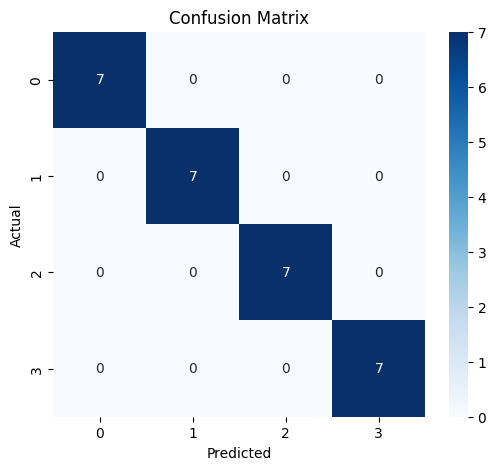

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import os
model_path = "/content/hand_sign_model.pkl"
joblib.dump(model, model_path)
print(f"\nModel saved to: {model_path}")


Model saved to: /content/hand_sign_model.pkl
